# Training the rBergomi WGAN-GP — on a 12 GB GPU, honestly

**The question this notebook answers:** *how far can a 5070 Ti Laptop (12 GB) actually go, and do the generated paths price options like the exact engine does?*

How to use: select the `.venv` kernel (`gpu-lab`), set `CONFIG` below, **Run All**. With the default config it's ~10–15 minutes end to end: two training chunks you can watch, the honest report card, and the economic verdict. Training is **chunked and checkpointed** — close the notebook mid-run, reopen, rerun the cell, and it resumes from the last checkpoint.

Everything mechanical lives in `wganlib.py` (smoke-tested end-to-end); this notebook is the story of one training run. The engine upstream of all this is validated 8/8 against exact references (`validate_rbergomi.py`), and the dataset on disk carries its own fingerprint checks (`build_dataset.py`).

In [1]:
import math, time, torch
import wganlib as wl

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert dev.type == "cuda", "this notebook wants the GPU (uv run jupyter ... from gpu-lab)"
print(f"device: {torch.cuda.get_device_name(0)}")
free, total = torch.cuda.mem_get_info()
print(f"VRAM: {total/2**20:,.0f} MiB total | {free/2**20:,.0f} MiB free")
torch.cuda.reset_peak_memory_stats()

device: NVIDIA GeForce RTX 5070 Ti Laptop GPU
VRAM: 12,199 MiB total | 11,042 MiB free


## The 12 GB map — measured, not estimated

`vram_probe.py` ran real training steps (critic + gradient-penalty double-backward, the true memory profile) at each config until the card gave out. Three findings:

| axis | result |
|---|---|
| **path length** (n_steps 64 → 2048) | nearly **free**: 92 → 129 MiB. The MLP's memory lives in its hidden layers, not the sequence. Longer paths cost training-data regeneration, not VRAM. |
| **width** (G 256 → 8192, D = 2×G) | the real frontier. G 1024/D 2048: 315 MiB at 57 ms/iter. G 4096/D 8192: 3.7 GB at 603 ms/iter. |
| **batch** (128 → 8192) | cheap: batch 8192 is only 1.2 GB. Batch buys gradient quality, not model capacity. |

**The wall is not where you'd expect.** G 8192/D 16384 didn't OOM on a 12 GB card — it silently *spilled* to system RAM (Windows CUDA fallback) at **14.5 seconds per iteration, a 250× slowdown**. On this machine the honest ceiling is what fits without spilling; past it, the GPU is a fiction.

Configs this notebook offers (pick one below):

| CONFIG | G / D width | peak VRAM | ms/iter | honest note |
|---|---|---|---|---|
| `"proven"` | 256 / 512 | ~130 MiB | ~34 | the prototype that passed roughness + leverage (4 PASS / 2 WARN at 12k iters) |
| `"big"` | 1024 / 2048 | ~315 MiB | ~57 | same speed as proven, 4× the capacity — unproven quality, our quality ceiling bet |
| `"max"` | 4096 / 8192 | ~3.8 GB | ~600 | 644 MiB of weights; fits, but ~10× slower per iter — use with patience (16k iters ≈ 2.7 h) |
| `"cliff"` | 8192 / 16384 | "fits" | ~14,500 | **don't** — spills to system RAM, 250× slowdown; documented as the honest wall |

In [2]:
# ---- the knob ----
CONFIG = "proven"   # "proven" | "big" | "max"   (see the table above)

SPECS = {
    "proven": dict(hidden_g=256,  hidden_d=512),
    "big":    dict(hidden_g=1024, hidden_d=2048),
    "max":    dict(hidden_g=4096, hidden_d=8192),
}
spec = SPECS[CONFIG]
N_ITERS_PER_CHUNK = 4000
N_CHUNKS = 2                     # total iters = N_ITERS_PER_CHUNK * N_CHUNKS
print(f"config: {CONFIG}  {spec} | training {N_ITERS_PER_CHUNK * N_CHUNKS} iters in {N_CHUNKS} chunks")

config: proven  {'hidden_g': 256, 'hidden_d': 512} | training 8000 iters in 2 chunks


In [3]:
# ---- the data (validated rBergomi return paths, see build_dataset.py) ----
data, meta = wl.load_data()
print(f"paths: {data.shape} on {data.device}")
print(f"model: H={meta['H']}, eta={meta['eta']}, rho={meta['rho']}, xi0={meta['xi0']}, T={meta['T']:.4f}y")

paths: torch.Size([100000, 64]) on cuda:0
model: H=0.1, eta=1.9, rho=-0.9, xi0=0.235, T=0.2540y


In [4]:
# ---- trainer (resumes automatically from the last checkpoint) ----
tr = wl.Trainer(data, depth=3, **spec)
tr.resume()

checkpoint has a different architecture — starting fresh


## Training, in reviewable chunks

Each `train(n)` call runs n generator iterations (5 critic steps each, gradient penalty λ=10), appends to the loss history, and checkpoints. Run more chunks if the curves say the run's still cooking; the checkpoint carries everything.

C:\Users\theon\Projects\gpu-lab\.venv\Lib\site-packages\torch\autograd\graph.py:1072: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:410.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


trained 4000 iters in 247s (62 ms/iter) | total 4000 iters


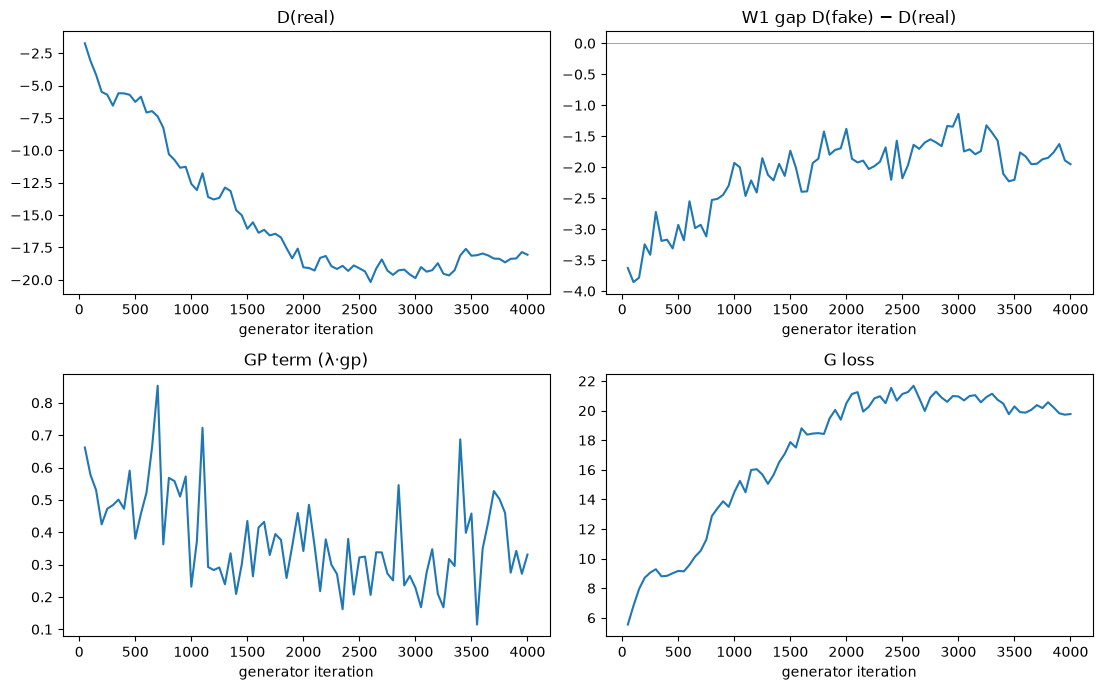

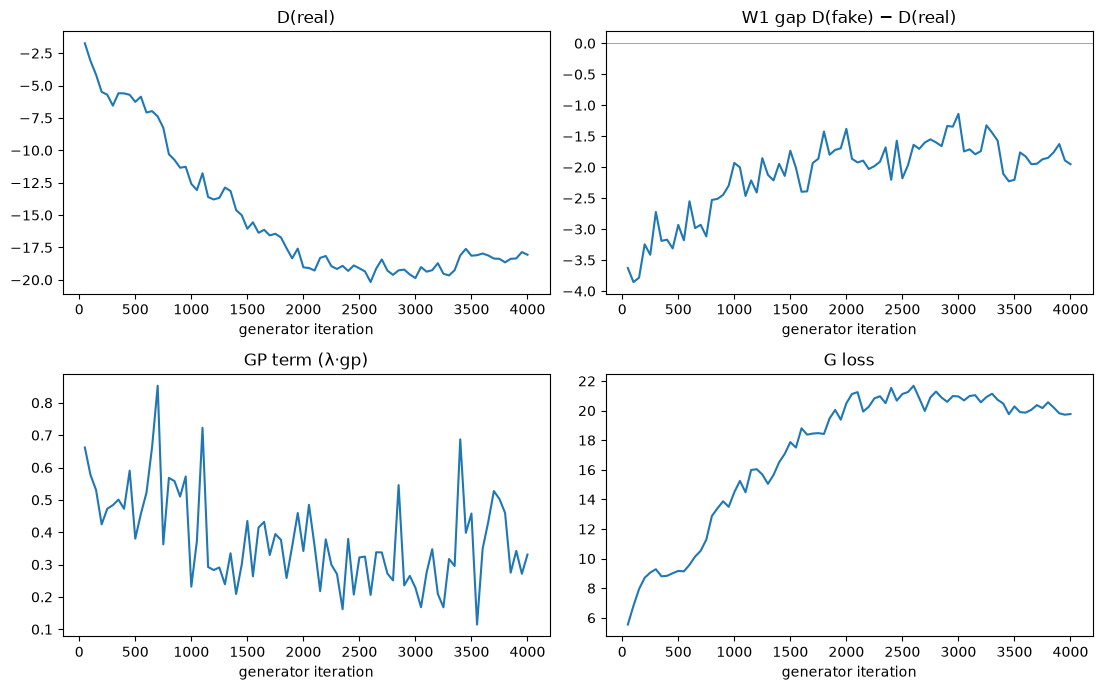

In [5]:
tr.train(N_ITERS_PER_CHUNK)
tr.plot_loss_curves()

trained 4000 iters in 126s (31 ms/iter) | total 8000 iters


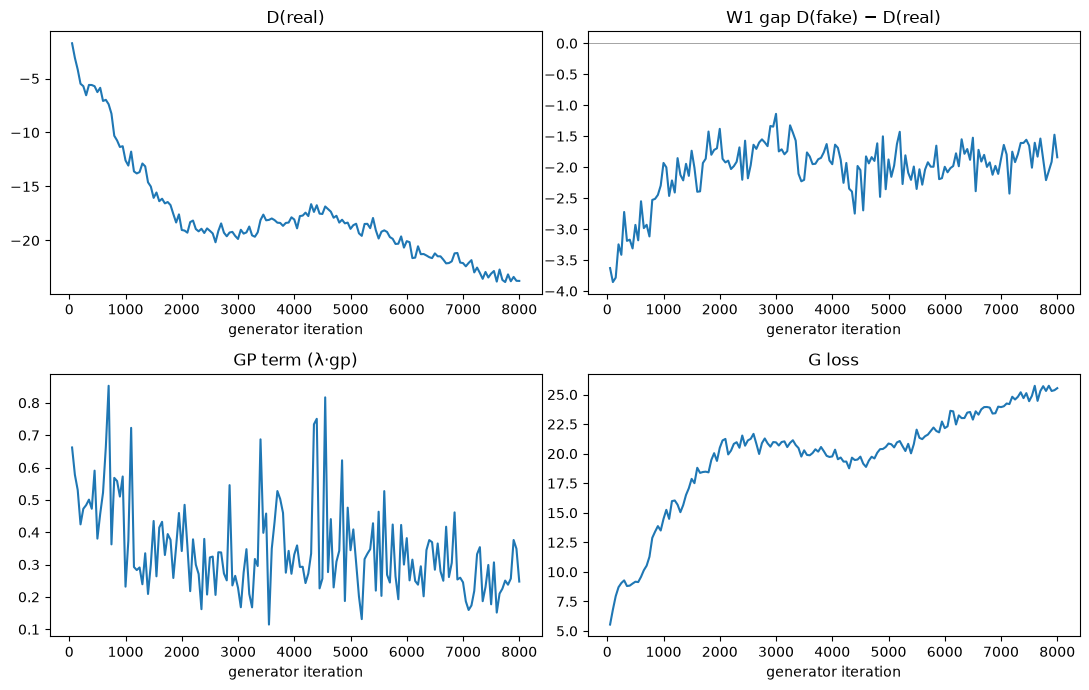

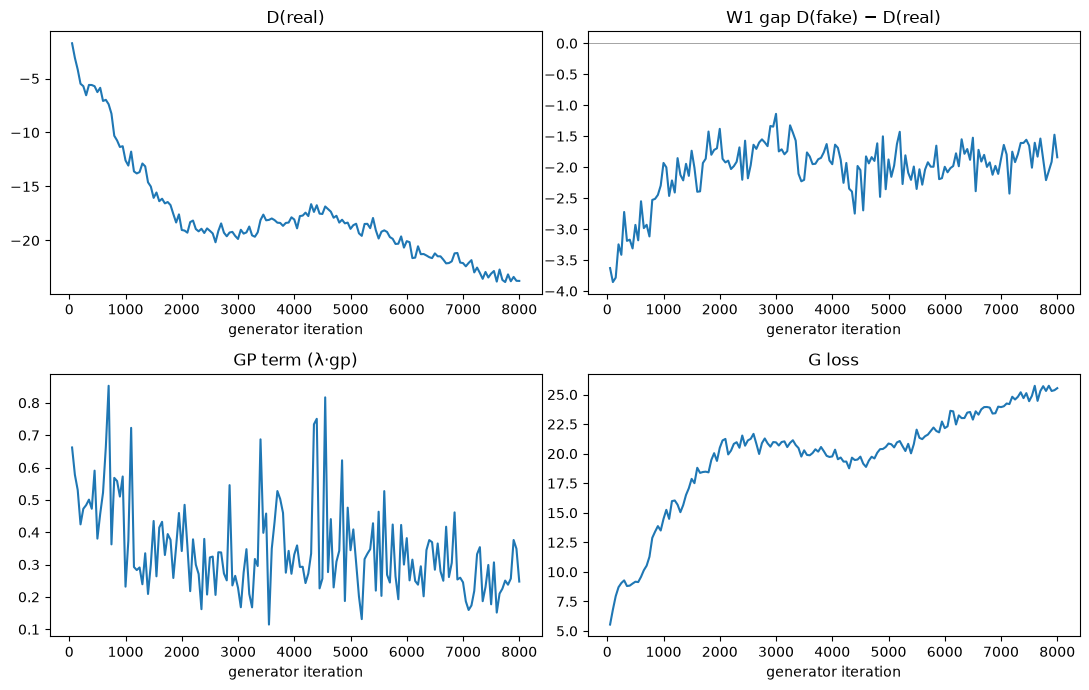

In [6]:
# second chunk — demonstrates resumability; add more cells if you want more
tr.train(N_ITERS_PER_CHUNK)
tr.plot_loss_curves()

## The honest report card

Metrics the critic was **never shown directly**: per-step moments, terminal distribution, the ACF of |returns| (volatility clustering), the roughness slope (the entire point of rough vol — theory says ≈ 2H−1 = −0.8 for the ACF of |r| at H=0.1), and the leverage proxy. Same metric code as `evaluate_wgan.py`, so numbers are comparable across runs.

In [7]:
metrics = tr.evaluate(n_gen=100_000)

==== honest report card (same metrics as evaluate_wgan.py) ====
  per-step mean (max |z| vs 4σ): +16.8162
  per-step std (max rel err): +0.1429
  Var[log S_T] (rel err): +0.1703
  E[log S_T] (err/0.1σm): +0.6689
  ACF|r| (mean abs dev): +0.0673
  roughness slope real: -0.3700
  roughness slope gen: -0.1934
  roughness slope |Δ|: +0.1766
  leverage real: -0.4112
  leverage gen: -0.2813
  leverage |Δ|: +0.1299


## The decisive test is economic, not statistical

Metrics are diagnostics; the arbiter is whether paths generated by the network **price a vanilla payoff like the exact engine does**. ATM European call, 200k paths each, MC errors stated, z-score between the two prices. Within 2σ: the generator didn't just learn statistics — it learned the part of the distribution a trader would actually pay for.

In [8]:
verdict = tr.price_call(n_paths=200_000, K=1.0)
for k, v in verdict.items():
    print(f"  {k}: {v}")

  K: 1.0
  GAN price: 0.06602587550878525
  GAN MC err: 0.00019769391309252382
  engine price: 0.08117048442363739
  engine MC err: 0.00021977025190273483
  z (GAN vs engine): -51.23272464429129
  note: within 2σ ⇒ generated paths price vanilla payoffs like the engine


In [9]:
peak = torch.cuda.max_memory_allocated() / 2**20
print(f"peak VRAM used by this notebook: {peak:,.0f} MiB of {total/2**20:,.0f} MiB")
print(f"headroom at CONFIG={CONFIG}: {total/2**20 - peak:,.0f} MiB — "
      f"{'comfortable' if total/2**20 - peak > 2000 else 'tight; next size up spills'}")

peak VRAM used by this notebook: 289 MiB of 12,199 MiB
headroom at CONFIG=proven: 11,911 MiB — comfortable


## Where this honestly stands

- **What "proven" gets you:** the prototype's verdict at 12k iters — roughness and leverage in PASS, marginal moments close, per-step mean profile at WARN. A *proof the pipeline works*, not a production scenario engine.
- **The realistic 12 GB ceiling:** `"max"` (G 4096 / D 8192) fits at 3.8 GB — capacity is not the binding constraint on this card. **Wall-clock is.** WGANs at MLP scale converge by iteration count, not FLOPs, so the honest frontier is how many ms/iter you'll tolerate: ~34 ms buys the proven size, ~600 ms buys max.
- **Length is free:** n_steps 64 → 2048 costs ~40 MiB. The expensive part of longer horizons is regenerating training data, not VRAM — an easy follow-up experiment.
- **Known next lever (not VRAM):** a 1D-convolutional critic over the path axis — structure-aware, and where the residual WARN metrics likely live.
- **The endgame this is all scaffolding for:** the same trainer, pointed at *real* return paths instead of rBergomi output. The exact engine is the practice run because it has ground truth; the market doesn't.

*The decisive test remains the one above: if the call price from generated paths doesn't match the engine, nothing else on this page matters.*